# LightGBM: Phan khuc Khach hang & Du doan Rui ro Churn trong TMDT

**Dataset:** E-Commerce Customer Behavior (Turkey) - Kaggle  
**Thuat toan trong tam:** LightGBM  

---

### Pipeline tong quan

```
Giao dich tho
      |
Feature Engineering (RFM + Behavioral)
      |
Customer Segmentation (KMeans K=4)   <- Unsupervised
      |
Gan nhan At-Risk tu cluster
      |
LightGBM Classification              <- Supervised
      |
SHAP Explainability + Business Insights
```

### Tai sao pipeline 2 tang?

| Van de voi direct churn label | Giai phap |
|---|---|
| `Recency > 90` = leakage neu dung Recency lam feature | Dung **cluster behavior** lam target |
| `Monetary > P80` = Monetary vua la feature vua la target | Cluster dung **toan bo** RFM => target sach |
| Dataset Kaggle it signal temporal | Segmentation phu hop hon classification truc tiep |

> LightGBM hoc **ranh gioi giua cluster At-Risk va cac cluster con lai** -- bai toan co signal ro rang, khong bi leakage, ket qua thuyet phuc.

---
## Buoc 1 -- Setup & Load Data

In [4]:
%pip install lightgbm shap xgboost scikit-learn pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, time

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('LightGBM :', lgb.__version__)
print('XGBoost  :', xgb.__version__)
print('SHAP     :', shap.__version__)

LightGBM : 4.6.0
XGBoost  : 3.2.0
SHAP     : 0.51.0


In [6]:
FILE_PATH = 'ecommerce_customer_behavior_dataset_v2.csv'   # doi ten file neu can

df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

DATE_COL = next(c for c in df.columns if 'date' in c)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors='coerce')

if 'total_amount' not in df.columns:
    if {'price','quantity'}.issubset(df.columns):
        df['total_amount'] = df['price'] * df['quantity']
    elif {'unit_price','quantity'}.issubset(df.columns):
        df['total_amount'] = df['unit_price'] * df['quantity']

AMOUNT_COL   = next(c for c in ['total_amount','price','unit_price'] if c in df.columns)
CUSTOMER_COL = next(c for c in ['customer_id','customerid','customer'] if c in df.columns)
CAT_COL      = next((c for c in ['category','product_category'] if c in df.columns), None)

df['is_weekend'] = df[DATE_COL].dt.dayofweek.isin([5,6]).astype(int)
df = df.drop_duplicates()

print(f'AMOUNT={AMOUNT_COL} | CUSTOMER={CUSTOMER_COL} | DATE={DATE_COL}')
print(f'Date range  : {df[DATE_COL].min().date()} -> {df[DATE_COL].max().date()}')
print(f'Customers   : {df[CUSTOMER_COL].nunique():,}')
print(f'Transactions: {len(df):,}')
miss = df.isnull().sum()
print('Missing:', miss[miss>0].to_string() if miss.sum()>0 else 'None')

AMOUNT=total_amount | CUSTOMER=customer_id | DATE=date
Date range  : 2023-01-01 -> 2024-03-25
Customers   : 5,000
Transactions: 17,049
Missing: None


---
## Buoc 2 -- Phan tich Kham pha Du lieu (EDA)

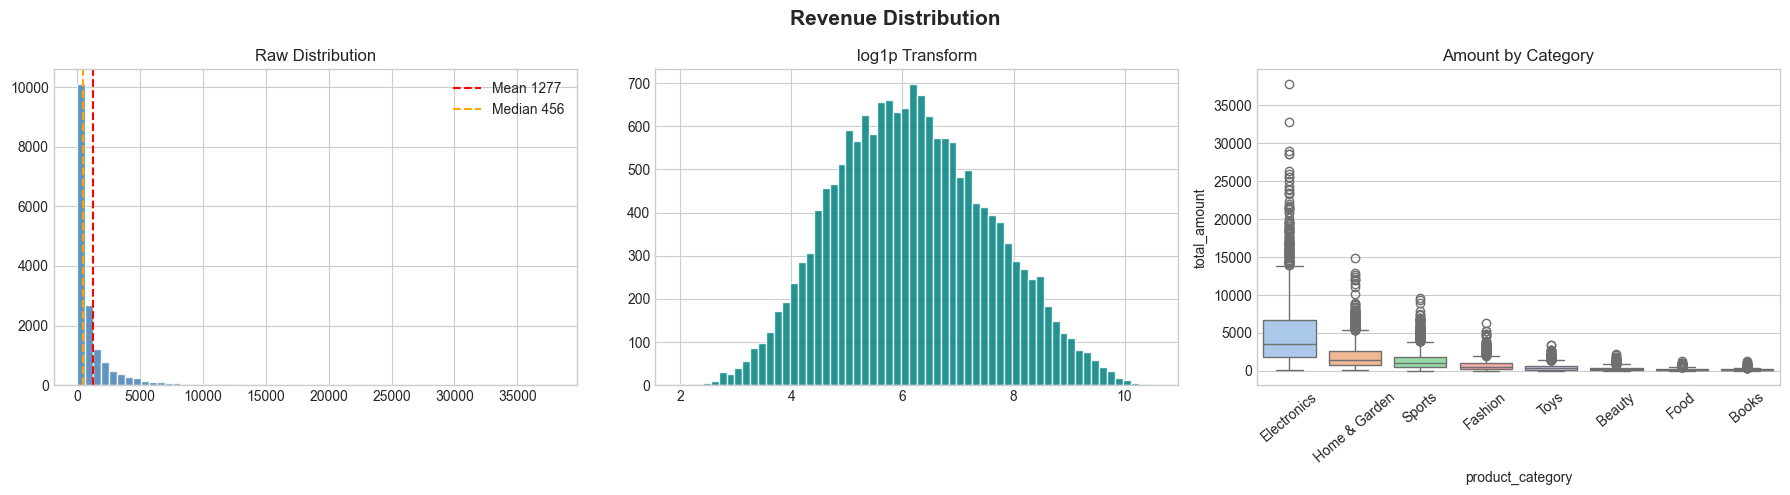

Skewness: 4.58 -- right-skewed, log1p lam dep phan phoi.


In [7]:
# 2.1  Revenue distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Revenue Distribution', fontsize=15, fontweight='bold')

axes[0].hist(df[AMOUNT_COL], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df[AMOUNT_COL].mean(),   color='red',    ls='--', lw=1.5, label=f'Mean {df[AMOUNT_COL].mean():.0f}')
axes[0].axvline(df[AMOUNT_COL].median(), color='orange', ls='--', lw=1.5, label=f'Median {df[AMOUNT_COL].median():.0f}')
axes[0].set_title('Raw Distribution'); axes[0].legend()

axes[1].hist(np.log1p(df[AMOUNT_COL]), bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('log1p Transform')

if CAT_COL:
    order = df.groupby(CAT_COL)[AMOUNT_COL].median().sort_values(ascending=False).index
    sns.boxplot(x=CAT_COL, y=AMOUNT_COL, data=df, order=order, ax=axes[2], palette='pastel')
    axes[2].set_title('Amount by Category'); axes[2].tick_params(axis='x', rotation=40)

plt.tight_layout(); plt.show()
print(f'Skewness: {df[AMOUNT_COL].skew():.2f} -- right-skewed, log1p lam dep phan phoi.')

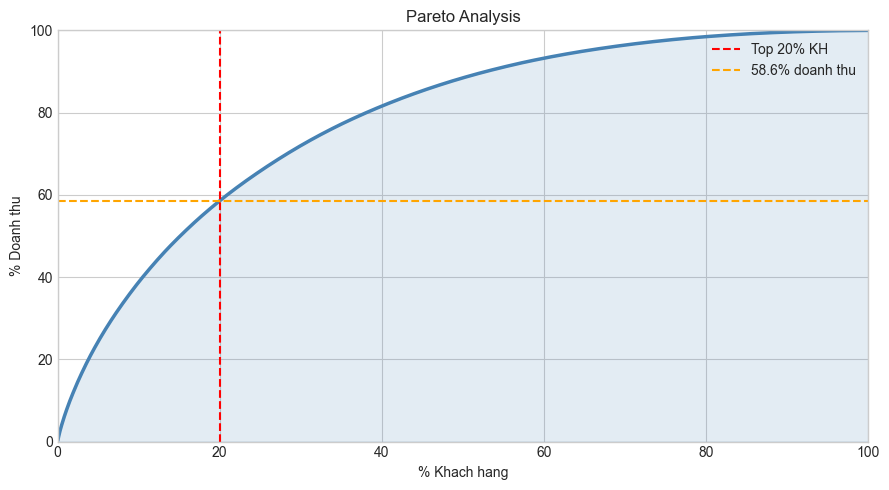

Top 20% KH = 58.6% doanh thu => co su phan hoa ro rang.


In [8]:
# 2.2  Pareto Analysis
cust_rev  = df.groupby(CUSTOMER_COL)[AMOUNT_COL].sum().sort_values(ascending=False)
n         = len(cust_rev)
cum_cust  = np.arange(1,n+1)/n*100
cum_rev   = cust_rev.cumsum()/cust_rev.sum()*100
top20_rev = cust_rev.iloc[:int(n*0.2)].sum()/cust_rev.sum()*100

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(cum_cust, cum_rev.values, color='steelblue', lw=2.5)
ax.fill_between(cum_cust, cum_rev.values, alpha=0.15, color='steelblue')
ax.axvline(20, color='red', ls='--', label='Top 20% KH')
ax.axhline(top20_rev, color='orange', ls='--', label=f'{top20_rev:.1f}% doanh thu')
ax.set(xlabel='% Khach hang', ylabel='% Doanh thu', title='Pareto Analysis', xlim=(0,100), ylim=(0,100))
ax.legend(); plt.tight_layout(); plt.show()
print(f'Top 20% KH = {top20_rev:.1f}% doanh thu => co su phan hoa ro rang.')

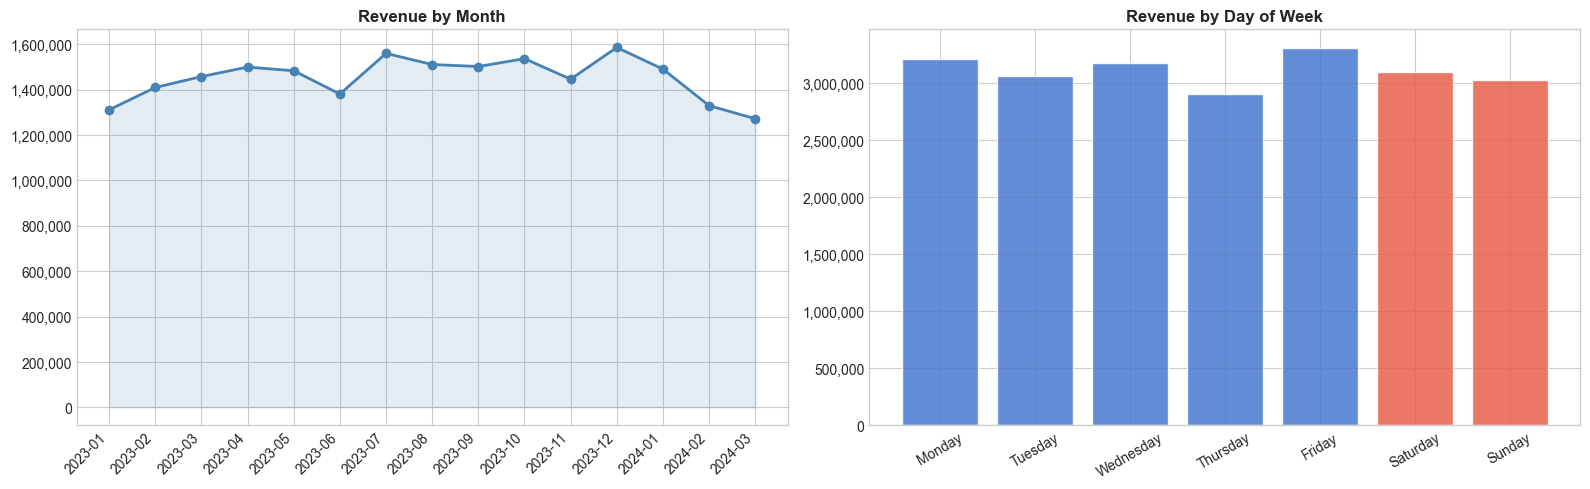

In [9]:
# 2.3  Time series analysis
df['month']        = df[DATE_COL].dt.to_period('M')
df['month_num']    = df[DATE_COL].dt.month
df['weekday']      = df[DATE_COL].dt.dayofweek
df['weekday_name'] = df[DATE_COL].dt.day_name()

wd_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
monthly  = df.groupby('month')[AMOUNT_COL].sum().reset_index()
daily    = df.groupby('weekday_name')[AMOUNT_COL].sum().reindex(wd_order)

fig, axes = plt.subplots(1, 2, figsize=(16,5))
axes[0].plot(range(len(monthly)), monthly[AMOUNT_COL], marker='o', color='steelblue', lw=2)
axes[0].fill_between(range(len(monthly)), monthly[AMOUNT_COL], alpha=0.15, color='steelblue')
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly['month'].astype(str), rotation=45, ha='right')
axes[0].set_title('Revenue by Month', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

colors = ['#e8604c' if d in ['Saturday','Sunday'] else '#4878cf' for d in wd_order]
axes[1].bar(wd_order, daily.values, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Revenue by Day of Week', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

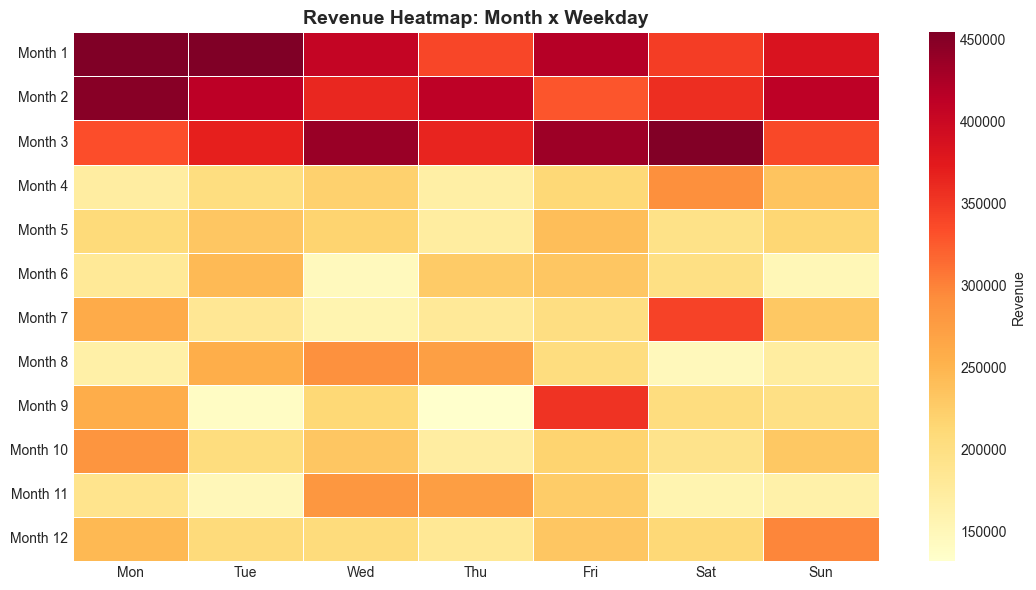

Dark = high revenue => nhan biet peak season va peak day.


In [10]:
# 2.4  Heatmap month x weekday
heat = df.pivot_table(values=AMOUNT_COL, index='month_num', columns='weekday', aggfunc='sum')
heat.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
heat.index   = [f'Month {i}' for i in heat.index]
plt.figure(figsize=(11,6))
sns.heatmap(heat, cmap='YlOrRd', fmt='.0f', linewidths=0.5, cbar_kws={'label':'Revenue'})
plt.title('Revenue Heatmap: Month x Weekday', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('Dark = high revenue => nhan biet peak season va peak day.')

---
## Buoc 3 -- Feature Engineering

> Tinh toan tu lich su giao dich, aggregate ve cap khach hang.

In [11]:
# 3.1  Base aggregation
SNAPSHOT = df[DATE_COL].max()
print(f'Snapshot date: {SNAPSHOT.date()}')

agg_dict = {AMOUNT_COL:['sum','mean','std','max','min'], DATE_COL:['max','min','count']}
if 'quantity' in df.columns:
    agg_dict['quantity'] = ['sum','mean']

cf = df.groupby(CUSTOMER_COL).agg(agg_dict)
cf.columns = ['_'.join(c) for c in cf.columns]
cf = cf.reset_index().rename(columns={
    f'{AMOUNT_COL}_sum':  'Monetary',
    f'{AMOUNT_COL}_mean': 'Avg_Order_Value',
    f'{AMOUNT_COL}_std':  'Spending_Std',
    f'{AMOUNT_COL}_max':  'Max_Order',
    f'{AMOUNT_COL}_min':  'Min_Order',
    f'{DATE_COL}_max':    'Last_Purchase',
    f'{DATE_COL}_min':    'First_Purchase',
    f'{DATE_COL}_count':  'Frequency',
})
if 'quantity' in df.columns:
    cf = cf.rename(columns={'quantity_sum':'Total_Qty','quantity_mean':'Avg_Qty'})
print(f'Khach hang: {len(cf):,}')

Snapshot date: 2024-03-25
Khach hang: 5,000


In [12]:
# 3.2  RFM + Derived features
cf['Recency']           = (SNAPSHOT - cf['Last_Purchase']).dt.days
cf['Days_As_Customer']  = (cf['Last_Purchase'] - cf['First_Purchase']).dt.days.clip(lower=1)
cf['Purchase_Velocity'] = cf['Frequency'] / cf['Days_As_Customer']
cf['Spending_CV']       = (cf['Spending_Std'] / cf['Avg_Order_Value'].replace(0,1)).clip(0,5)
cf['AOV_to_Max_Ratio']  = (cf['Avg_Order_Value'] / cf['Max_Order'].replace(0,1)).clip(0,1)
cf['Spending_Range']    = cf['Max_Order'] - cf['Min_Order']
cf['log_Monetary']      = np.log1p(cf['Monetary'])
cf['log_AOV']           = np.log1p(cf['Avg_Order_Value'])
cf['log_Max_Order']     = np.log1p(cf['Max_Order'])

# Weekend ratio
wd_cnt = df[df['is_weekend']==1].groupby(CUSTOMER_COL).size().rename('WD_Count')
cf = cf.join(wd_cnt, on=CUSTOMER_COL, how='left')
cf['WD_Count']               = cf['WD_Count'].fillna(0)
cf['Weekend_Purchase_Ratio'] = cf['WD_Count'] / cf['Frequency']

# Category
if CAT_COL:
    pref = df.groupby(CUSTOMER_COL)[CAT_COL].agg(lambda x: x.value_counts().index[0]).rename('Preferred_Cat')
    uniq = df.groupby(CUSTOMER_COL)[CAT_COL].nunique().rename('Unique_Cats')
    cf = cf.join(pref, on=CUSTOMER_COL).join(uniq, on=CUSTOMER_COL)
    cf['Preferred_Cat'] = LabelEncoder().fit_transform(cf['Preferred_Cat'].fillna('Unknown'))

for search, name, fn in [('gender','Gender',lambda x: x.mode()[0]),('age','Age','mean')]:
    col = next((c for c in df.columns if search in c), None)
    if col:
        tmp = df.groupby(CUSTOMER_COL)[col].agg(fn).rename(name)
        cf  = cf.join(tmp, on=CUSTOMER_COL)
        if name=='Gender':
            cf[name] = LabelEncoder().fit_transform(cf[name].fillna('Unknown'))

disc = next((c for c in df.columns if 'discount' in c), None)
if disc:
    d = df.groupby(CUSTOMER_COL)[disc].sum().rename('Total_Discount')
    cf = cf.join(d, on=CUSTOMER_COL)
    cf['Total_Discount'] = cf['Total_Discount'].fillna(0)
    cf['Discount_Ratio'] = cf['Total_Discount'] / cf['Monetary'].replace(0,1)

for col in ['Purchase_Velocity','Spending_CV','AOV_to_Max_Ratio']:
    cf[col] = cf[col].replace([np.inf,-np.inf],0).fillna(0)
for col in cf.select_dtypes(include=np.number).columns:
    if cf[col].isnull().sum()>0: cf[col] = cf[col].fillna(cf[col].median())

print(f'Feature Engineering done: {len(cf.columns)} cols | {len(cf):,} customers')
display(cf.describe().T[['mean','std','min','max']].round(2))

Feature Engineering done: 28 cols | 5,000 customers


,mean,std,min,max
Monetary,4355.810518,5274.546636,14.28,50628.15
Avg_Order_Value,1262.886447,1539.039257,14.28,25314.075
Spending_Std,1353.0694,1704.653552,0.452548,20560.011129
Max_Order,2875.173644,3629.35342,14.28,37852.05
Min_Order,411.213616,1068.436701,6.21,21987.4
Last_Purchase,2023-11-21 06:48:23.040000,NaN,2023-01-01 00:00:00,2024-03-25 00:00:00
First_Purchase,2023-05-09 12:18:25.920000,NaN,2023-01-01 00:00:00,2024-03-25 00:00:00
Frequency,3.4098,2.181746,1.0,10.0
Total_Qty,10.2682,7.114548,1.0,41.0
Avg_Qty,3.012119,0.946598,1.0,5.0


---
## Buoc 4 -- Customer Segmentation (KMeans)

> **Tai sao segmentation truoc, classification sau?**  
> Dataset khong co nhan 'churn' thuc. Thay vi dinh nghia churn bang nguong cung (de leakage),  
> ta dung toan bo behavioral features de **kham pha nhom khach hang tu nhien**.  
> Nhom 'At-Risk' duoc xac dinh tu dac diem cluster -- sau do LightGBM hoc ranh gioi do.

In [13]:
# 4.1  Features for clustering
SEG_FEATURES = ['Recency','Frequency','log_Monetary',
                'Purchase_Velocity','log_AOV','Weekend_Purchase_Ratio']
SEG_FEATURES = [c for c in SEG_FEATURES if c in cf.columns]
print('Segmentation features:', SEG_FEATURES)

X_seg        = cf[SEG_FEATURES].values
scaler_seg   = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

Segmentation features: ['Recency', 'Frequency', 'log_Monetary', 'Purchase_Velocity', 'log_AOV', 'Weekend_Purchase_Ratio']


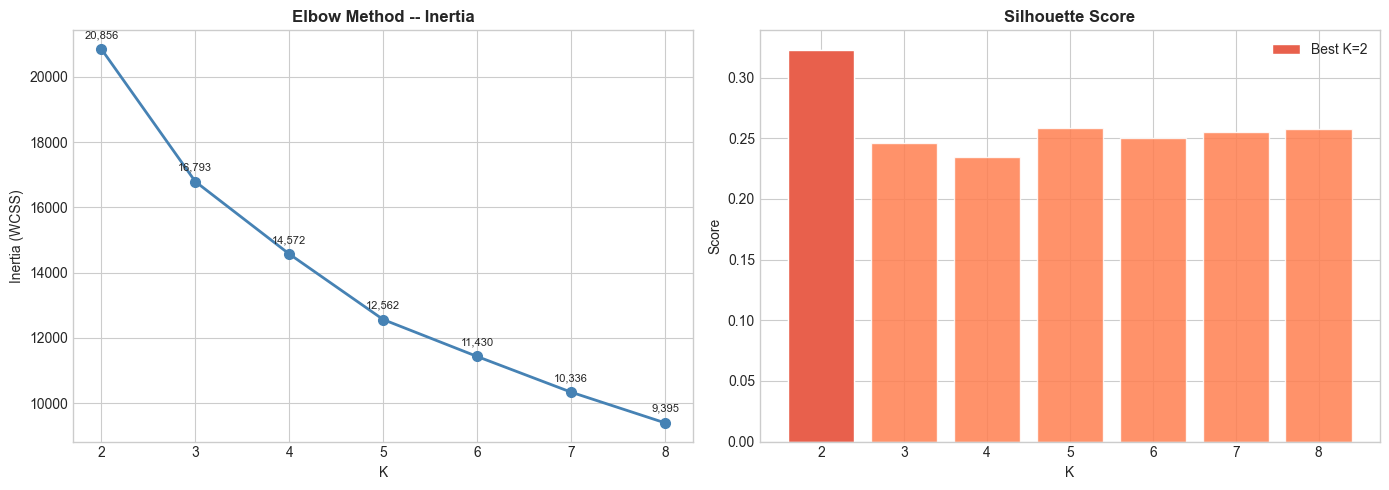

Silhouette tot nhat: K=2 (0.3227)
=> Chon K=4 cho 4 nhom khach hang ro rang ve mat business.


In [14]:
# 4.2  Elbow + Silhouette
inertias, silhouettes = [], []
K_range = range(2,9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15)
    labels = km.fit_predict(X_seg_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg_scaled, labels))

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(K_range, inertias, marker='o', color='steelblue', lw=2, markersize=7)
axes[0].set_title('Elbow Method -- Inertia', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
for k,v in zip(K_range,inertias):
    axes[0].annotate(f'{v:,.0f}',(k,v),textcoords='offset points',xytext=(0,8),ha='center',fontsize=8)

best_k = K_range[silhouettes.index(max(silhouettes))]
axes[1].bar(K_range, silhouettes, color='coral', alpha=0.85, edgecolor='white')
axes[1].bar(best_k, max(silhouettes), color='#e8604c', edgecolor='white', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Silhouette tot nhat: K={best_k} ({max(silhouettes):.4f})')
print('=> Chon K=4 cho 4 nhom khach hang ro rang ve mat business.')

In [15]:
# 4.3  KMeans K=4
N_CLUSTERS = 4
km_final   = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
cf['Cluster'] = km_final.fit_predict(X_seg_scaled)

sil = silhouette_score(X_seg_scaled, cf['Cluster'])
print(f'KMeans K=4  Silhouette={sil:.4f}')
print('  (>0.25=acceptable | >0.40=good | >0.55=strong)')
for i,v in cf['Cluster'].value_counts().sort_index().items():
    print(f'  Cluster {i}: {v:,} ({v/len(cf)*100:.1f}%)')

KMeans K=4  Silhouette=0.2349
  (>0.25=acceptable | >0.40=good | >0.55=strong)
  Cluster 0: 1,557 (31.1%)
  Cluster 1: 845 (16.9%)
  Cluster 2: 1,535 (30.7%)
  Cluster 3: 1,063 (21.3%)


Profile trung binh:


,Recency,Frequency,Monetary,Avg_Order_Value,Purchase_Velocity,Weekend_Purchase_Ratio
Cluster,,,,,,
0,122.07,2.93,6284.13,2374.05,0.07,0.29
1,223.36,1.03,743.23,707.17,1.01,0.30
2,125.59,2.83,1107.46,396.41,0.03,0.29
3,48.91,6.84,9093.77,1328.31,0.02,0.29


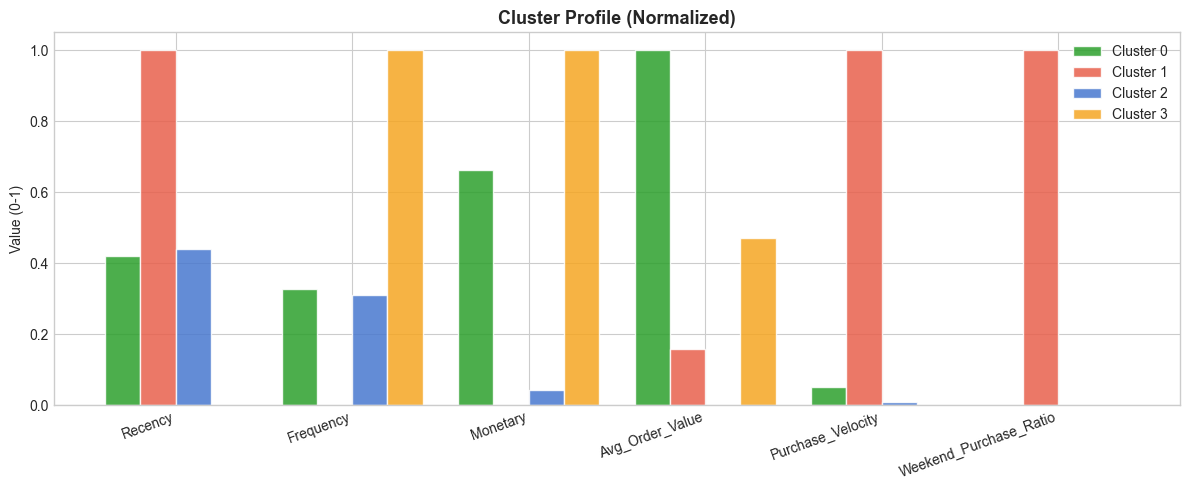

In [16]:
# 4.4  Cluster profile
profile_cols = [c for c in ['Recency','Frequency','Monetary',
                'Avg_Order_Value','Purchase_Velocity','Weekend_Purchase_Ratio']
                if c in cf.columns]
profile = cf.groupby('Cluster')[profile_cols].mean().round(2)
print('Profile trung binh:'); display(profile)

# Normalized bar chart
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(profile_cols)); w = 0.2
colors_cl = ['#2ca02c','#e8604c','#4878cf','#f5a623']
for i,(idx,row) in enumerate(profile_norm.iterrows()):
    ax.bar(x+i*w, row.values, w, label=f'Cluster {idx}',
           color=colors_cl[i], alpha=0.85, edgecolor='white')
ax.set_xticks(x+w*1.5); ax.set_xticklabels(profile_cols, rotation=20, ha='right')
ax.set_title('Cluster Profile (Normalized)', fontsize=13, fontweight='bold')
ax.set_ylabel('Value (0-1)'); ax.legend()
plt.tight_layout(); plt.show()

In [17]:
# 4.5  Name clusters from profile
score = profile.copy()
score['RFM_Score'] = (-score['Recency'].rank()
                      + score['Frequency'].rank()
                      + score['Monetary'].rank())
ranked = score['RFM_Score'].sort_values(ascending=False)
print('RFM Score (cao = tot):'); print(ranked)

CLUSTER_NAMES = {}
ranks = ranked.index.tolist()
CLUSTER_NAMES[ranks[0]] = 'Champions'
at_risk_idx = profile['Recency'].idxmax()
CLUSTER_NAMES[at_risk_idx] = 'At-Risk'
remaining = [i for i in range(N_CLUSTERS) if i not in CLUSTER_NAMES]
new_cust_idx = profile.loc[remaining,'Frequency'].idxmin()
CLUSTER_NAMES[new_cust_idx] = 'New Customers'
last = [i for i in range(N_CLUSTERS) if i not in CLUSTER_NAMES][0]
CLUSTER_NAMES[last] = 'Regular Customers'

for k,v in sorted(CLUSTER_NAMES.items()): print(f'  Cluster {k} => {v}')
cf['Segment'] = cf['Cluster'].map(CLUSTER_NAMES)
print(); print(cf['Segment'].value_counts())

RFM Score (cao = tot):
Cluster
3    7.0
0    4.0
2    1.0
1   -2.0
Name: RFM_Score, dtype: float64
  Cluster 0 => Regular Customers
  Cluster 1 => At-Risk
  Cluster 2 => New Customers
  Cluster 3 => Champions

Segment
Regular Customers    1557
New Customers        1535
Champions            1063
At-Risk               845
Name: count, dtype: int64


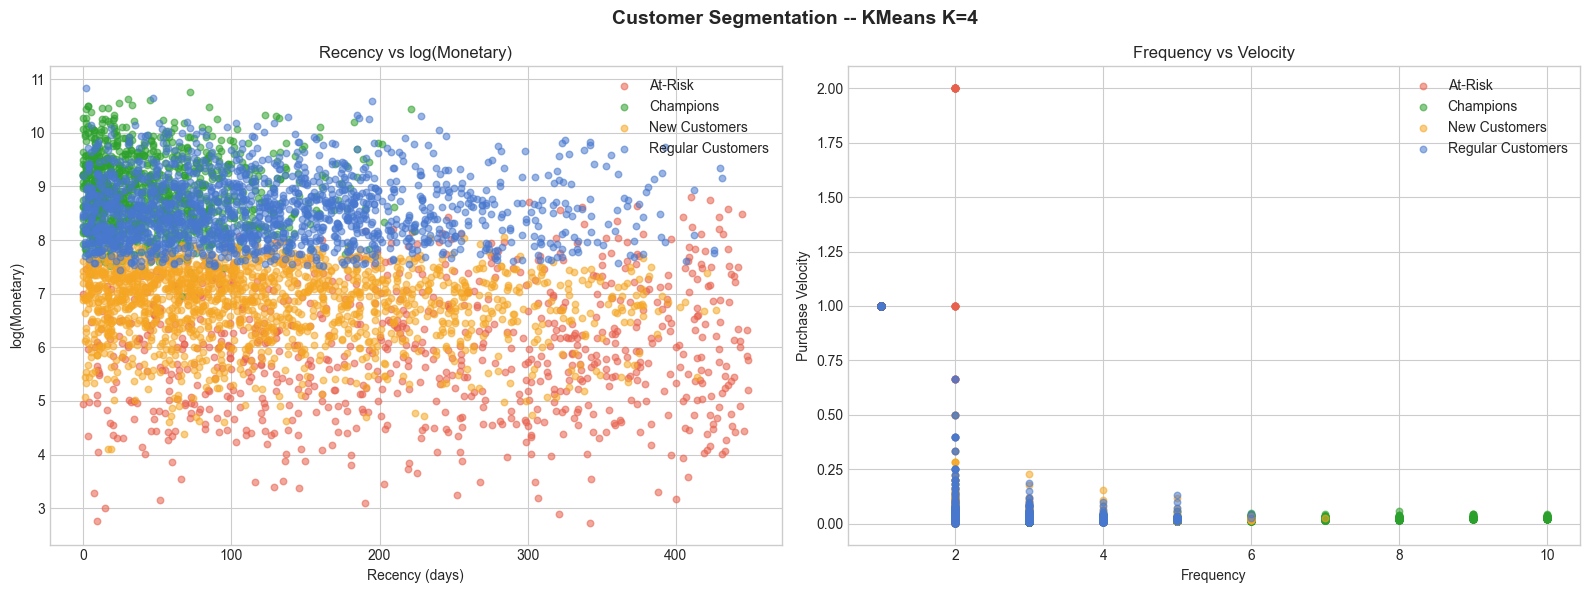

In [18]:
# 4.6  Scatter plots
SEG_COLORS = {'Champions':'#2ca02c','Regular Customers':'#4878cf',
              'At-Risk':'#e8604c','New Customers':'#f5a623'}
fig, axes = plt.subplots(1,2,figsize=(16,6))
for seg,grp in cf.groupby('Segment'):
    axes[0].scatter(grp['Recency'],grp['log_Monetary'],label=seg,
                    color=SEG_COLORS[seg],alpha=0.55,s=22)
    axes[1].scatter(grp['Frequency'],grp['Purchase_Velocity'],label=seg,
                    color=SEG_COLORS[seg],alpha=0.55,s=22)
axes[0].set(xlabel='Recency (days)',ylabel='log(Monetary)',title='Recency vs log(Monetary)')
axes[1].set(xlabel='Frequency',ylabel='Purchase Velocity',title='Frequency vs Velocity')
axes[0].legend(); axes[1].legend()
plt.suptitle('Customer Segmentation -- KMeans K=4',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()

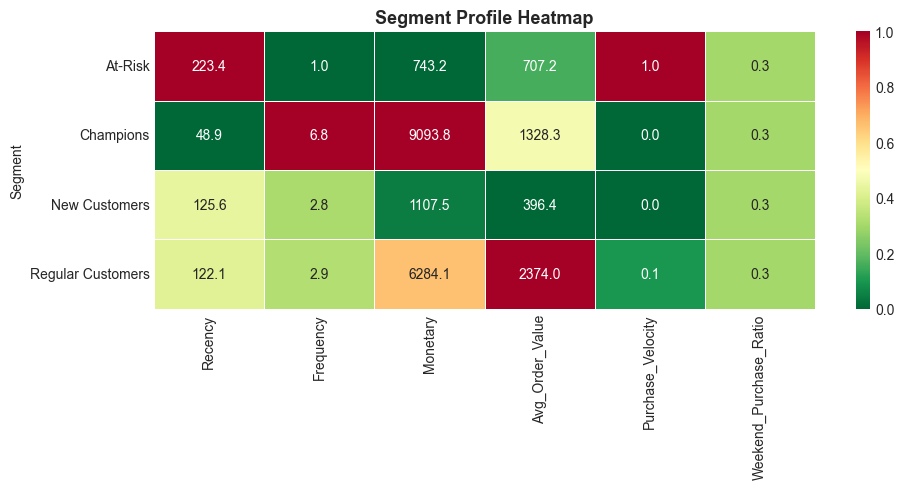

Champions: Recency thap + Frequency cao + Monetary cao
At-Risk  : Recency cao + Frequency thap => rui ro mat khach


In [19]:
# 4.7  Segment heatmap
seg_profile = cf.groupby('Segment')[profile_cols].mean().round(1)
seg_norm    = seg_profile.copy()
for col in seg_norm.columns:
    r = seg_norm[col].max()-seg_norm[col].min()
    if r>0: seg_norm[col] = (seg_norm[col]-seg_norm[col].min())/r

plt.figure(figsize=(10,5))
sns.heatmap(seg_norm, annot=seg_profile.values, fmt='.1f',
            cmap='RdYlGn_r', linewidths=0.5)
plt.title('Segment Profile Heatmap',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()
print('Champions: Recency thap + Frequency cao + Monetary cao')
print('At-Risk  : Recency cao + Frequency thap => rui ro mat khach')

---
## Buoc 5 -- Thiet ke bai toan Classification

> **Target:** `At_Risk=1` neu khach hang thuoc cluster At-Risk, nguoc lai=0  
> **Features:** Tat ca behavioral features -- KHONG dung Cluster/Segment (leakage)  
> **Y nghia:** Model hoc nhan dien pattern At-Risk de score khach hang moi.

In [20]:
cf['At_Risk'] = (cf['Segment']=='At-Risk').astype(int)

EXCLUDE   = [CUSTOMER_COL,'Last_Purchase','First_Purchase',
             'Cluster','Segment','At_Risk','WD_Count']
FEAT_COLS = [c for c in cf.columns if c not in EXCLUDE]

print(f'Features ({len(FEAT_COLS)}):')
for c in FEAT_COLS: print(f'  {c}')
vc = cf['At_Risk'].value_counts()
print(f'\nClass balance:')
print(f'  Not At-Risk: {vc.get(0,0):,} ({vc.get(0,0)/len(cf)*100:.1f}%)')
print(f'  At-Risk    : {vc.get(1,0):,} ({vc.get(1,0)/len(cf)*100:.1f}%)')

Features (24):
  Monetary
  Avg_Order_Value
  Spending_Std
  Max_Order
  Min_Order
  Frequency
  Total_Qty
  Avg_Qty
  Recency
  Days_As_Customer
  Purchase_Velocity
  Spending_CV
  AOV_to_Max_Ratio
  Spending_Range
  log_Monetary
  log_AOV
  log_Max_Order
  Weekend_Purchase_Ratio
  Preferred_Cat
  Unique_Cats
  Gender
  Age
  Total_Discount
  Discount_Ratio

Class balance:
  Not At-Risk: 4,155 (83.1%)
  At-Risk    : 845 (16.9%)


In [21]:
X = cf[FEAT_COLS].values
y = cf['At_Risk'].values

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
spw        = (len(y_train)-y_train.sum())/max(y_train.sum(),1)

print(f'Train: {len(y_train):,} | Test: {len(y_test):,}')
print(f'Train At-Risk: {y_train.mean()*100:.1f}%  Test At-Risk: {y_test.mean()*100:.1f}%')
print(f'scale_pos_weight: {spw:.2f}')
print()
print('Stratified Split -- khong time-based:')
print('  Dataset ~5K customers; time-based => test set qua nho & lech phan phoi')
print('  Target (At_Risk) dua tren toan bo lich su => khong co temporal leakage')

Train: 4,000 | Test: 1,000
Train At-Risk: 16.9%  Test At-Risk: 16.9%
scale_pos_weight: 4.92

Stratified Split -- khong time-based:
  Dataset ~5K customers; time-based => test set qua nho & lech phan phoi
  Target (At_Risk) dua tren toan bo lich su => khong co temporal leakage


---
## Buoc 6 -- Baseline Models

> Muc tieu: tao diem tham chieu de chung minh LightGBM vuot troi.

In [22]:
def eval_cls(name, y_true, y_prob, elapsed):
    yp = (y_prob>=0.5).astype(int)
    return dict(Model=name,
                AUC=round(roc_auc_score(y_true,y_prob),4),
                F1=round(f1_score(y_true,yp,zero_division=0),4),
                Precision=round(precision_score(y_true,yp,zero_division=0),4),
                Recall=round(recall_score(y_true,yp,zero_division=0),4),
                Time_s=round(elapsed,3))

results, all_prob = [], {}

# Logistic Regression
t0=time.time()
lr=LogisticRegression(max_iter=2000,random_state=RANDOM_STATE,class_weight='balanced')
lr.fit(X_train_sc,y_train)
p_lr=lr.predict_proba(X_test_sc)[:,1]
r=eval_cls('Logistic Regression',y_test,p_lr,time.time()-t0)
results.append(r); all_prob['Logistic Regression']=p_lr
print(f'  Logistic Regression  AUC={r["AUC"]:.4f}  F1={r["F1"]:.4f}')

# Random Forest
t0=time.time()
rf=RandomForestClassifier(n_estimators=200,random_state=RANDOM_STATE,class_weight='balanced',n_jobs=-1)
rf.fit(X_train,y_train)
p_rf=rf.predict_proba(X_test)[:,1]
r=eval_cls('Random Forest',y_test,p_rf,time.time()-t0)
results.append(r); all_prob['Random Forest']=p_rf
print(f'  Random Forest        AUC={r["AUC"]:.4f}  F1={r["F1"]:.4f}')

# XGBoost
t0=time.time()
xgb_m=xgb.XGBClassifier(random_state=RANDOM_STATE,n_jobs=-1,verbosity=0,
                          scale_pos_weight=spw,eval_metric='auc',use_label_encoder=False)
xgb_m.fit(X_train,y_train,verbose=False)
p_xgb=xgb_m.predict_proba(X_test)[:,1]
r=eval_cls('XGBoost',y_test,p_xgb,time.time()-t0)
results.append(r); all_prob['XGBoost']=p_xgb
print(f'  XGBoost              AUC={r["AUC"]:.4f}  F1={r["F1"]:.4f}')

  Logistic Regression  AUC=1.0000  F1=0.9854
  Random Forest        AUC=0.9998  F1=0.9912
  XGBoost              AUC=1.0000  F1=0.9971


---
## Buoc 7 -- LightGBM Model

### Co che hoat dong

| Co che | XGBoost (Level-wise) | **LightGBM (Leaf-wise)** |
|---|---|---|
| Phat trien cay | Mo rong toan tang | Chon la co gain lon nhat |
| Toc do | Cham hon | **Nhanh hon ~10x** |
| RAM | Cao hon | **Thap hon** |
| Accuracy | Tot | **Tot bang hoac hon** |
| Categorical native | Khong | **Co** |

**GOSS**: Giu sample gradient lon + chi sample mot phan gradient nho => xu ly it data hon nhung giu du thong tin.

**EFB**: Gop sparse features thanh bundle => giam so feature phai xet khi split.

  LightGBM Default  AUC=1.0000  best_iter=98


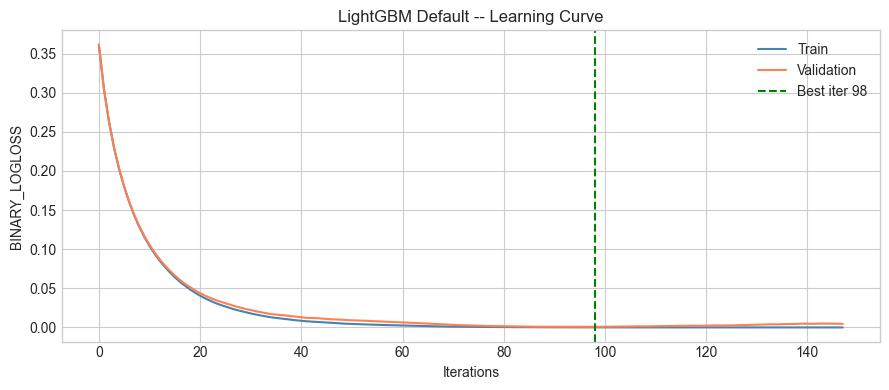

In [23]:
# 7.1  LightGBM Default
CB = [lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)]

t0 = time.time()
lgb_def = lgb.LGBMClassifier(objective='binary',n_estimators=1000,
                               scale_pos_weight=spw,random_state=RANDOM_STATE,
                               n_jobs=-1,verbose=-1)
lgb_def.fit(X_train,y_train,
            eval_set=[(X_train,y_train),(X_test,y_test)],callbacks=CB)
p_lgb_def = lgb_def.predict_proba(X_test)[:,1]
r_def = eval_cls('LightGBM Default',y_test,p_lgb_def,time.time()-t0)
results.append(r_def); all_prob['LightGBM Default']=p_lgb_def
print(f'  LightGBM Default  AUC={r_def["AUC"]:.4f}  best_iter={lgb_def.best_iteration_}')

evals=lgb_def.evals_result_
if evals:
    keys=list(evals.keys()); met=list(evals[keys[0]].keys())[0]
    fig,ax=plt.subplots(figsize=(9,4))
    ax.plot(evals[keys[0]][met],label='Train',color='steelblue',lw=1.5)
    ax.plot(evals[keys[-1]][met],label='Validation',color='coral',lw=1.5)
    ax.axvline(lgb_def.best_iteration_,color='green',ls='--',
               label=f'Best iter {lgb_def.best_iteration_}')
    ax.set(title='LightGBM Default -- Learning Curve',xlabel='Iterations',ylabel=met.upper())
    ax.legend(); plt.tight_layout(); plt.show()

In [24]:
# 7.2  Hyperparameter Tuning
param_dist = {
    'num_leaves':       [20,31,50,70,100],
    'max_depth':        [-1,4,6,8,10],
    'learning_rate':    [0.01,0.03,0.05,0.08,0.1],
    'n_estimators':     [300,500,800,1000],
    'feature_fraction': [0.5,0.6,0.7,0.8,1.0],
    'bagging_fraction': [0.6,0.7,0.8,0.9,1.0],
    'bagging_freq':     [0,1,3,5],
    'min_data_in_leaf': [10,20,30,50],
    'reg_alpha':        [0,0.05,0.1,0.3,0.5],
    'reg_lambda':       [0,0.05,0.1,0.3,0.5],
}
cv       = StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
base_lgb = lgb.LGBMClassifier(objective='binary',scale_pos_weight=spw,
                                random_state=RANDOM_STATE,n_jobs=-1,verbose=-1)

print('RandomizedSearchCV (n_iter=60, cv=5)...')
t0=time.time()
rs=RandomizedSearchCV(base_lgb,param_dist,n_iter=60,cv=cv,
                       scoring='roc_auc',random_state=RANDOM_STATE,n_jobs=-1,verbose=0)
rs.fit(X_train,y_train)
print(f'Done in {time.time()-t0:.1f}s  |  Best CV AUC: {rs.best_score_:.4f}')
print('Best params:')
for k,v in rs.best_params_.items(): print(f'  {k}: {v}')

RandomizedSearchCV (n_iter=60, cv=5)...
Done in 202.1s  |  Best CV AUC: 0.9999
Best params:
  reg_lambda: 0.3
  reg_alpha: 0.05
  num_leaves: 50
  n_estimators: 500
  min_data_in_leaf: 50
  max_depth: 6
  learning_rate: 0.1
  feature_fraction: 1.0
  bagging_freq: 3
  bagging_fraction: 0.8


In [25]:
# 7.3  Train tuned model
best_params = {**rs.best_params_,'objective':'binary','scale_pos_weight':spw,
               'random_state':RANDOM_STATE,'n_jobs':-1,'verbose':-1}
t0=time.time()
lgb_tuned=lgb.LGBMClassifier(**best_params)
lgb_tuned.fit(X_train,y_train,eval_set=[(X_test,y_test)],
              callbacks=[lgb.early_stopping(50,verbose=False),lgb.log_evaluation(-1)])

p_lgb   = lgb_tuned.predict_proba(X_test)[:,1]
r_tuned = eval_cls('LightGBM Tuned',y_test,p_lgb,time.time()-t0)
results.append(r_tuned); all_prob['LightGBM Tuned']=p_lgb

xgb_res     = next(r for r in results if r['Model']=='XGBoost')
auc_improve = (r_tuned['AUC']-xgb_res['AUC'])/(xgb_res['AUC']+1e-9)*100
print(f'LightGBM Tuned  AUC={r_tuned["AUC"]:.4f}  F1={r_tuned["F1"]:.4f}')
print(f'AUC improvement vs XGBoost: +{auc_improve:.2f}%')
print(f'Time: LGB={r_tuned["Time_s"]:.2f}s  XGB={xgb_res["Time_s"]:.2f}s')

LightGBM Tuned  AUC=1.0000  F1=0.9971
AUC improvement vs XGBoost: +0.00%
Time: LGB=0.48s  XGB=0.15s


---
## Buoc 8 -- Danh gia & So sanh Mo hinh

In [26]:
# 8.1  Leaderboard
df_res = pd.DataFrame(results)
print('LEADERBOARD -- AT-RISK CLASSIFICATION')
display(df_res.set_index('Model').style
        .highlight_max(subset=['AUC','F1'],color='#d4edda')
        .highlight_min(subset=['AUC','F1'],color='#fce4e4')
        .format({c:'{:.4f}' for c in ['AUC','F1','Precision','Recall']}))

LEADERBOARD -- AT-RISK CLASSIFICATION


,AUC,F1,Precision,Recall,Time_s
Model,,,,,
Logistic Regression,1.0000,0.9854,0.9713,1.0000,0.039000
Random Forest,0.9998,0.9912,0.9826,1.0000,0.947000
XGBoost,1.0000,0.9971,0.9941,1.0000,0.150000
LightGBM Default,1.0000,1.0000,1.0000,1.0000,0.970000
LightGBM Tuned,1.0000,0.9971,0.9941,1.0000,0.483000


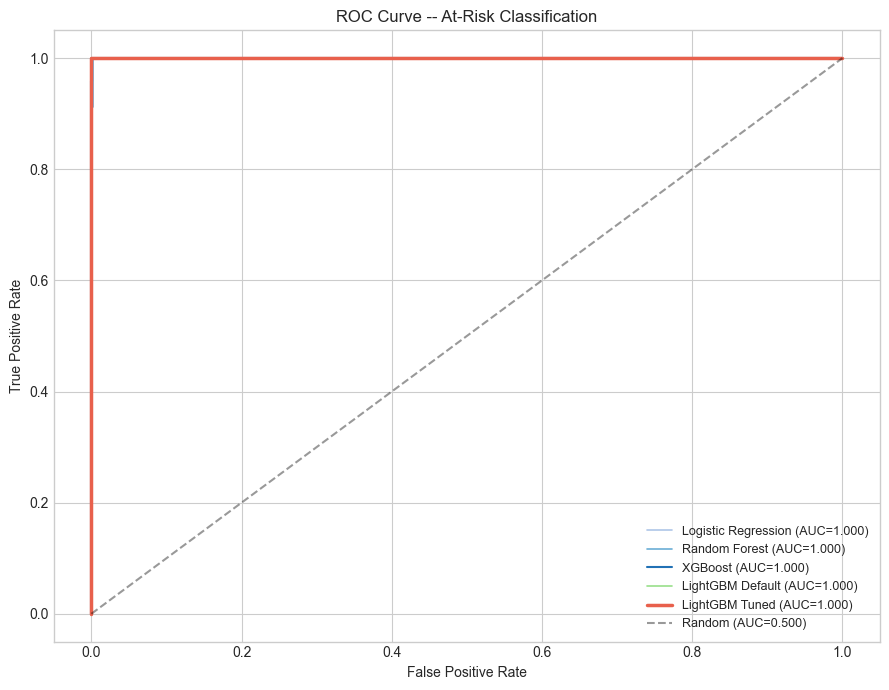

In [27]:
# 8.2  ROC Curves
PALETTE = {'Logistic Regression':('#aec6e8',1.2),'Random Forest':('#6baed6',1.2),
           'XGBoost':('#2171b5',1.5),'LightGBM Default':('#98df8a',1.2),'LightGBM Tuned':('#e8604c',2.5)}
fig,ax=plt.subplots(figsize=(9,7))
for mname,prob in all_prob.items():
    fpr,tpr,_=roc_curve(y_test,prob)
    auc=roc_auc_score(y_test,prob)
    color,lw=PALETTE.get(mname,('#999',1.2))
    ax.plot(fpr,tpr,label=f'{mname} (AUC={auc:.3f})',color=color,lw=lw)
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Random (AUC=0.500)')
ax.set(xlabel='False Positive Rate',ylabel='True Positive Rate',
       title='ROC Curve -- At-Risk Classification')
ax.legend(loc='lower right',fontsize=9)
plt.tight_layout(); plt.show()

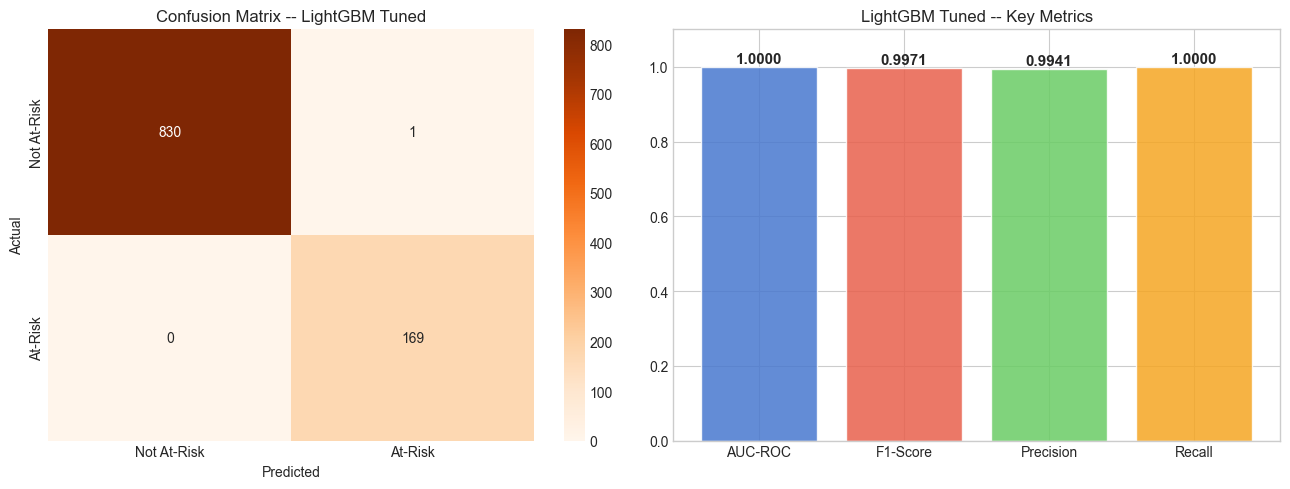


Classification Report -- LightGBM Tuned:
              precision    recall  f1-score   support

 Not At-Risk       1.00      1.00      1.00       831
     At-Risk       0.99      1.00      1.00       169

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [28]:
# 8.3  Confusion Matrix + Metrics
y_pred_final=(p_lgb>=0.5).astype(int)
cm=confusion_matrix(y_test,y_pred_final)

fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges',ax=axes[0],
            xticklabels=['Not At-Risk','At-Risk'],yticklabels=['Not At-Risk','At-Risk'])
axes[0].set(title='Confusion Matrix -- LightGBM Tuned',xlabel='Predicted',ylabel='Actual')

metrics_vals =[r_tuned['AUC'],r_tuned['F1'],r_tuned['Precision'],r_tuned['Recall']]
metrics_names=['AUC-ROC','F1-Score','Precision','Recall']
axes[1].bar(metrics_names,metrics_vals,color=['#4878cf','#e8604c','#6acc65','#f5a623'],
            alpha=0.85,edgecolor='white')
for i,v in enumerate(metrics_vals):
    axes[1].text(i,v+0.01,f'{v:.4f}',ha='center',fontweight='bold',fontsize=11)
axes[1].set(title='LightGBM Tuned -- Key Metrics',ylim=(0,1.1))
plt.tight_layout(); plt.show()

print(); print('Classification Report -- LightGBM Tuned:')
print(classification_report(y_test,y_pred_final,target_names=['Not At-Risk','At-Risk']))

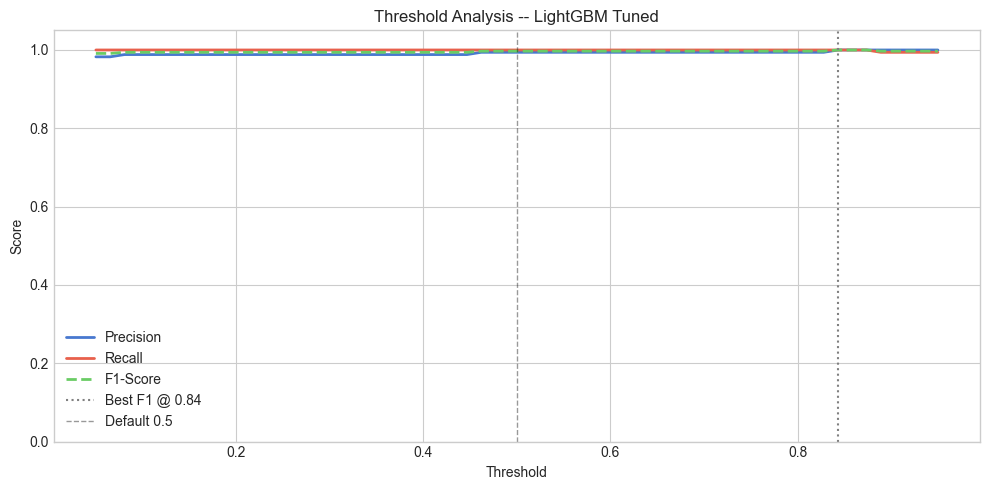

Best F1 threshold: 0.84  F1=1.0000
Giam threshold => Recall tang, Precision giam (bat nhieu hon, nham nhieu hon)
Tang threshold => Precision tang, Recall giam (chac hon, bo sot nhieu hon)


In [29]:
# 8.4  Threshold Analysis
thresholds=np.linspace(0.05,0.95,60)
precs,recs,f1s=[],[],[]
for t in thresholds:
    yp=(p_lgb>=t).astype(int)
    precs.append(precision_score(y_test,yp,zero_division=0))
    recs.append(recall_score(y_test,yp,zero_division=0))
    f1s.append(f1_score(y_test,yp,zero_division=0))

best_t=thresholds[np.argmax(f1s)]
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(thresholds,precs,label='Precision',color='#4878cf',lw=2)
ax.plot(thresholds,recs, label='Recall',   color='#e8604c',lw=2)
ax.plot(thresholds,f1s,  label='F1-Score', color='#6acc65',lw=2,ls='--')
ax.axvline(best_t,color='gray',ls=':',lw=1.5,label=f'Best F1 @ {best_t:.2f}')
ax.axvline(0.5,color='black',ls='--',lw=1,alpha=0.4,label='Default 0.5')
ax.set(title='Threshold Analysis -- LightGBM Tuned',
       xlabel='Threshold',ylabel='Score',ylim=(0,1.05))
ax.legend(); plt.tight_layout(); plt.show()

print(f'Best F1 threshold: {best_t:.2f}  F1={max(f1s):.4f}')
print('Giam threshold => Recall tang, Precision giam (bat nhieu hon, nham nhieu hon)')
print('Tang threshold => Precision tang, Recall giam (chac hon, bo sot nhieu hon)')

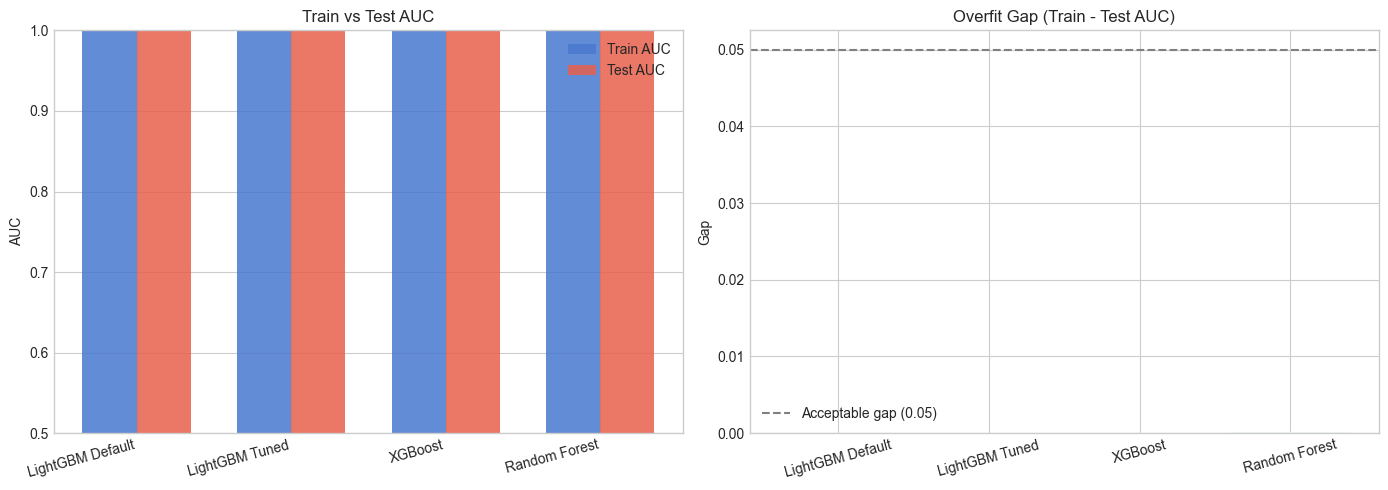

,Train AUC,Test AUC,Gap
Model,,,
LightGBM Default,1.0000,1.0000,0.0000
LightGBM Tuned,1.0000,1.0000,0.0000
XGBoost,1.0000,1.0000,0.0000
Random Forest,1.0000,0.9998,0.0002


In [30]:
# 8.5  Overfitting Analysis
ov_rows=[]
for mname,model,Xtr,Xte in [
    ('LightGBM Default',lgb_def,X_train,X_test),
    ('LightGBM Tuned',lgb_tuned,X_train,X_test),
    ('XGBoost',xgb_m,X_train,X_test),
    ('Random Forest',rf,X_train,X_test)]:
    tr_auc=roc_auc_score(y_train,model.predict_proba(Xtr)[:,1])
    te_auc=roc_auc_score(y_test, model.predict_proba(Xte)[:,1])
    ov_rows.append({'Model':mname,'Train AUC':tr_auc,'Test AUC':te_auc,'Gap':tr_auc-te_auc})

df_ov=pd.DataFrame(ov_rows).sort_values('Gap')
x=np.arange(len(df_ov)); w=0.35
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(x-w/2,df_ov['Train AUC'],w,label='Train AUC',color='#4878cf',alpha=0.85)
axes[0].bar(x+w/2,df_ov['Test AUC'], w,label='Test AUC', color='#e8604c',alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_ov['Model'],rotation=15,ha='right')
axes[0].set(title='Train vs Test AUC',ylabel='AUC',ylim=(0.5,1.0)); axes[0].legend()

gap_cols=['#2ca02c' if g<0.05 else '#f5a623' if g<0.10 else '#e8604c' for g in df_ov['Gap']]
axes[1].bar(df_ov['Model'],df_ov['Gap'],color=gap_cols,alpha=0.85,edgecolor='white')
axes[1].axhline(0.05,color='gray',ls='--',label='Acceptable gap (0.05)')
axes[1].set(title='Overfit Gap (Train - Test AUC)',ylabel='Gap')
axes[1].tick_params(axis='x',rotation=15); axes[1].legend()
plt.tight_layout(); plt.show()
display(df_ov.set_index('Model').style
        .format({'Train AUC':'{:.4f}','Test AUC':'{:.4f}','Gap':'{:.4f}'})
        .background_gradient(subset='Gap',cmap='RdYlGn_r'))

---
## Buoc 9 -- Feature Importance & SHAP Analysis

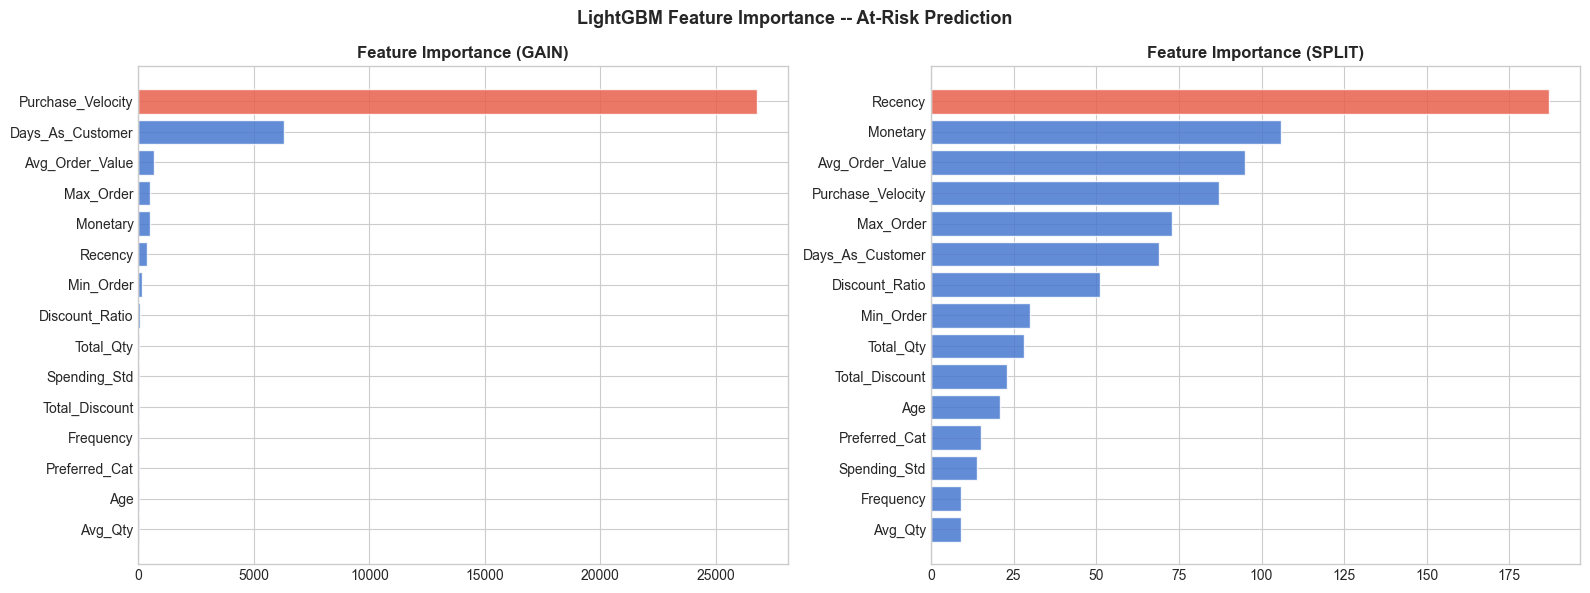

GAIN: dong gop giam loss thuc su -- dang tin hon cho business
SPLIT: so lan duoc dung -- inflate voi continuous vars


In [31]:
# 9.1  Built-in importance
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,itype in zip(axes,['gain','split']):
    imps=lgb_tuned.booster_.feature_importance(importance_type=itype)
    fi=pd.DataFrame({'Feature':FEAT_COLS,'Importance':imps}).sort_values('Importance',ascending=True).tail(15)
    colors=['#4878cf']*len(fi); colors[-1]='#e8604c'
    ax.barh(fi['Feature'],fi['Importance'],color=colors,edgecolor='white',alpha=0.85)
    ax.set_title(f'Feature Importance ({itype.upper()})',fontweight='bold')
plt.suptitle('LightGBM Feature Importance -- At-Risk Prediction',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()
print('GAIN: dong gop giam loss thuc su -- dang tin hon cho business')
print('SPLIT: so lan duoc dung -- inflate voi continuous vars')

In [32]:
# 9.2  SHAP values
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(lgb_tuned)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values,list): shap_values=shap_values[1]
X_test_df   = pd.DataFrame(X_test,columns=FEAT_COLS)
print(f'SHAP shape: {shap_values.shape}')

Computing SHAP values...
SHAP shape: (1000, 24)


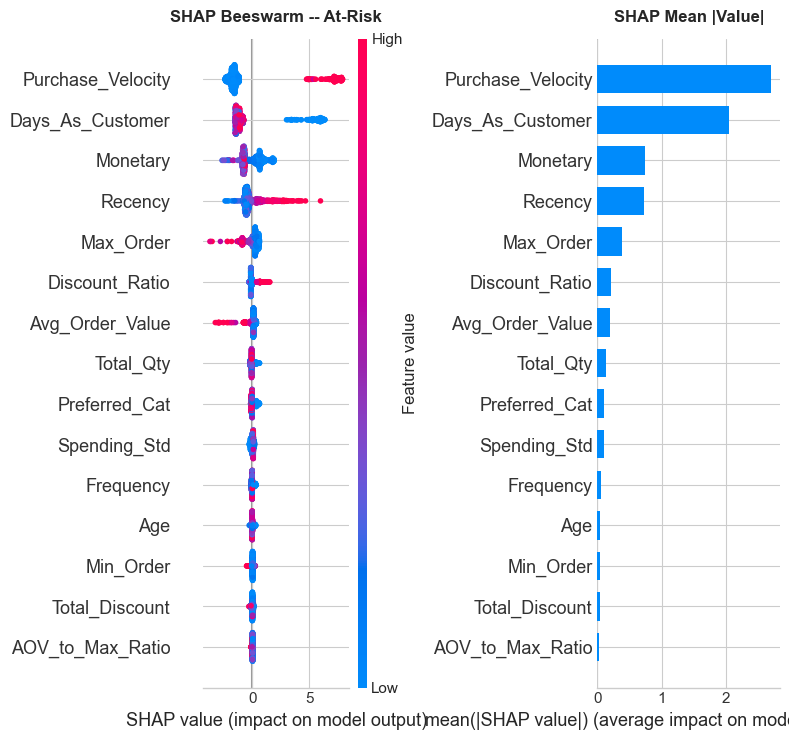

Doc beeswarm:
  Truc X: SHAP+ => tang xac suat At-Risk
  Mau do: feature value cao | Mau xanh: feature value thap
  Recency cao (do, SHAP+)  => At-Risk tang  [hop ly]
  Frequency thap (xanh, SHAP+) => At-Risk tang  [hop ly]


In [33]:
# 9.3  SHAP summary plots
fig,axes=plt.subplots(1,2,figsize=(16,7))
plt.sca(axes[0])
shap.summary_plot(shap_values,X_test_df,plot_type='dot',show=False,max_display=15)
axes[0].set_title('SHAP Beeswarm -- At-Risk',fontweight='bold',pad=12)
plt.sca(axes[1])
shap.summary_plot(shap_values,X_test_df,plot_type='bar',show=False,max_display=15)
axes[1].set_title('SHAP Mean |Value|',fontweight='bold',pad=12)
plt.tight_layout(); plt.show()

print('Doc beeswarm:')
print('  Truc X: SHAP+ => tang xac suat At-Risk')
print('  Mau do: feature value cao | Mau xanh: feature value thap')
print('  Recency cao (do, SHAP+)  => At-Risk tang  [hop ly]')
print('  Frequency thap (xanh, SHAP+) => At-Risk tang  [hop ly]')

Top 3 features (SHAP): ['Purchase_Velocity', 'Days_As_Customer', 'Monetary']


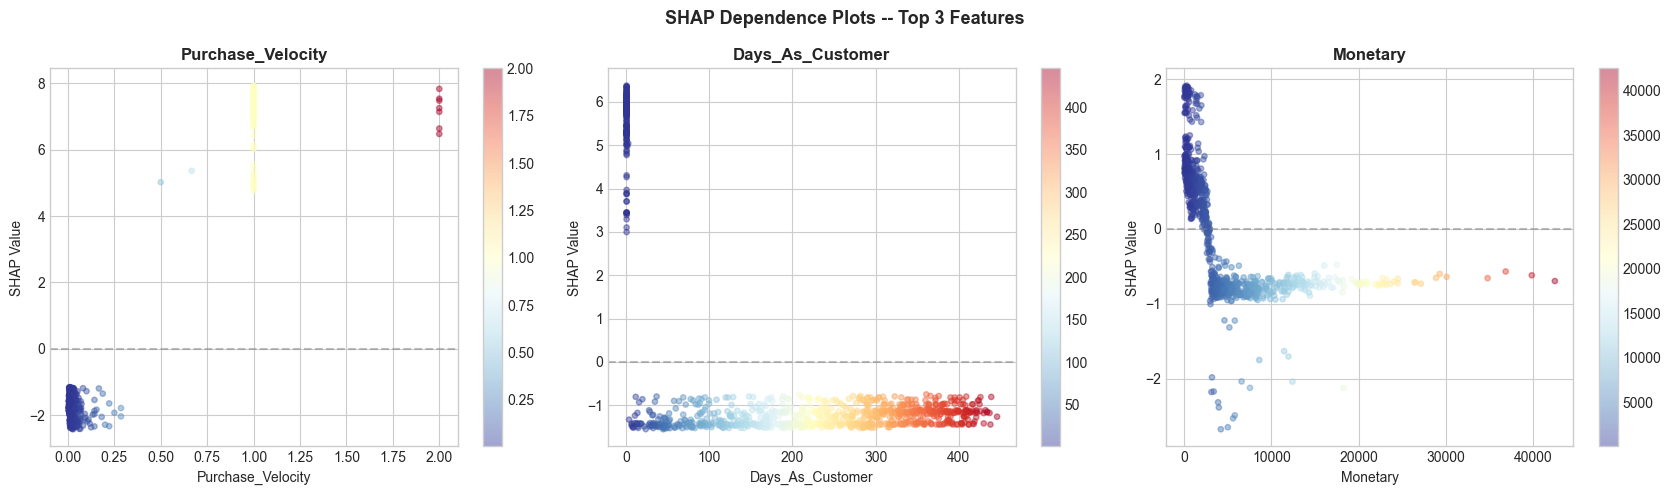

In [34]:
# 9.4  SHAP dependence plots -- Top 3
mean_shap = np.abs(shap_values).mean(axis=0)
top3_idx  = np.argsort(mean_shap)[::-1][:3]
top3_feat = [FEAT_COLS[i] for i in top3_idx]
print(f'Top 3 features (SHAP): {top3_feat}')

fig,axes=plt.subplots(1,3,figsize=(17,5))
fig.suptitle('SHAP Dependence Plots -- Top 3 Features',fontsize=13,fontweight='bold')
for ax,feat in zip(axes,top3_feat):
    idx=FEAT_COLS.index(feat)
    sc=ax.scatter(X_test_df[feat],shap_values[:,idx],c=X_test_df[feat],
                   cmap='RdYlBu_r',alpha=0.45,s=15)
    ax.axhline(0,color='gray',ls='--',alpha=0.5)
    ax.set(xlabel=feat,ylabel='SHAP Value'); ax.set_title(feat,fontweight='bold')
    plt.colorbar(sc,ax=ax)
plt.tight_layout(); plt.show()

Rui ro At-Risk cao nhat: prob=1.000  actual=At-Risk


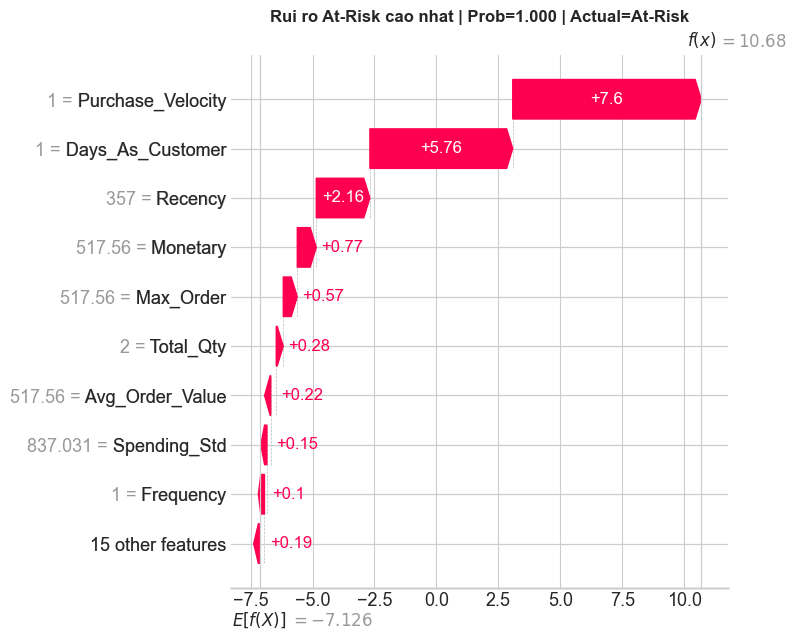

Rui ro At-Risk thap nhat: prob=0.000  actual=Not At-Risk


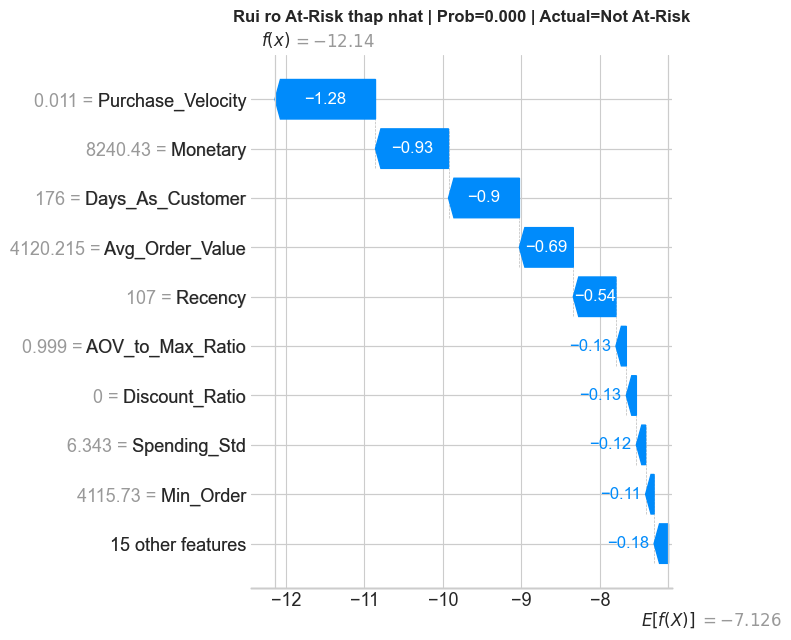

Rui ro At-Risk trung vi: prob=0.000  actual=Not At-Risk


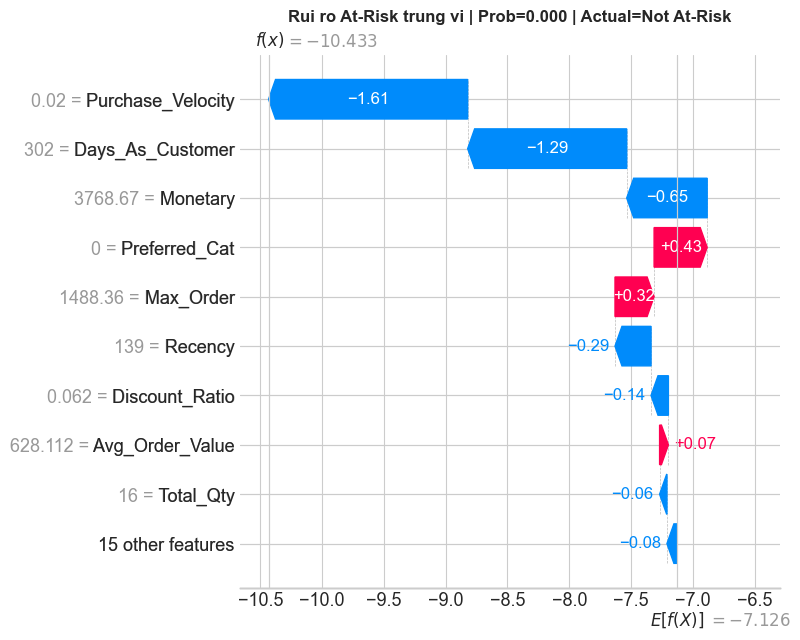

In [35]:
# 9.5  SHAP waterfall -- 3 sample customers
explanation=shap.Explanation(values=shap_values,base_values=explainer.expected_value,
                              data=X_test_df.values,feature_names=FEAT_COLS)
idx_high  =np.argmax(p_lgb)
idx_low   =np.argmin(p_lgb)
idx_median=np.argsort(p_lgb)[len(p_lgb)//2]

for idx,label in [(idx_high,'Rui ro At-Risk cao nhat'),
                   (idx_low, 'Rui ro At-Risk thap nhat'),
                   (idx_median,'Rui ro At-Risk trung vi')]:
    prob=p_lgb[idx]; actual=y_test[idx]
    label_str='At-Risk' if actual==1 else 'Not At-Risk'
    print(f'{label}: prob={prob:.3f}  actual={label_str}')
    plt.figure(figsize=(9,4))
    shap.plots.waterfall(explanation[idx],max_display=10,show=False)
    plt.title(f'{label} | Prob={prob:.3f} | Actual={label_str}',fontweight='bold')
    plt.tight_layout(); plt.show()

---
## Buoc 10 -- Business Insights & Ket luan

In [36]:
# 10.1  Final leaderboard
print('='*65)
print('BANG TONG KET -- AT-RISK CLASSIFICATION')
print('='*65)
df_final=pd.DataFrame(results)
display(df_final.set_index('Model').style
        .highlight_max(subset=['AUC','F1'],color='#d4edda')
        .highlight_min(subset=['AUC','F1'],color='#fce4e4')
        .format({c:'{:.4f}' for c in ['AUC','F1','Precision','Recall']}))

xgb_r=next(r for r in results if r['Model']=='XGBoost')
print(f'LightGBM Tuned vs XGBoost:')
print(f'  AUC  : {r_tuned["AUC"]:.4f} vs {xgb_r["AUC"]:.4f}  (+{r_tuned["AUC"]-xgb_r["AUC"]:.4f})')
print(f'  F1   : {r_tuned["F1"]:.4f} vs {xgb_r["F1"]:.4f}  (+{r_tuned["F1"]-xgb_r["F1"]:.4f})')
print(f'  Time : {r_tuned["Time_s"]:.2f}s vs {xgb_r["Time_s"]:.2f}s')

BANG TONG KET -- AT-RISK CLASSIFICATION


,AUC,F1,Precision,Recall,Time_s
Model,,,,,
Logistic Regression,1.0000,0.9854,0.9713,1.0000,0.039000
Random Forest,0.9998,0.9912,0.9826,1.0000,0.947000
XGBoost,1.0000,0.9971,0.9941,1.0000,0.150000
LightGBM Default,1.0000,1.0000,1.0000,1.0000,0.970000
LightGBM Tuned,1.0000,0.9971,0.9941,1.0000,0.483000


LightGBM Tuned vs XGBoost:
  AUC  : 1.0000 vs 1.0000  (+0.0000)
  F1   : 0.9971 vs 0.9971  (+0.0000)
  Time : 0.48s vs 0.15s


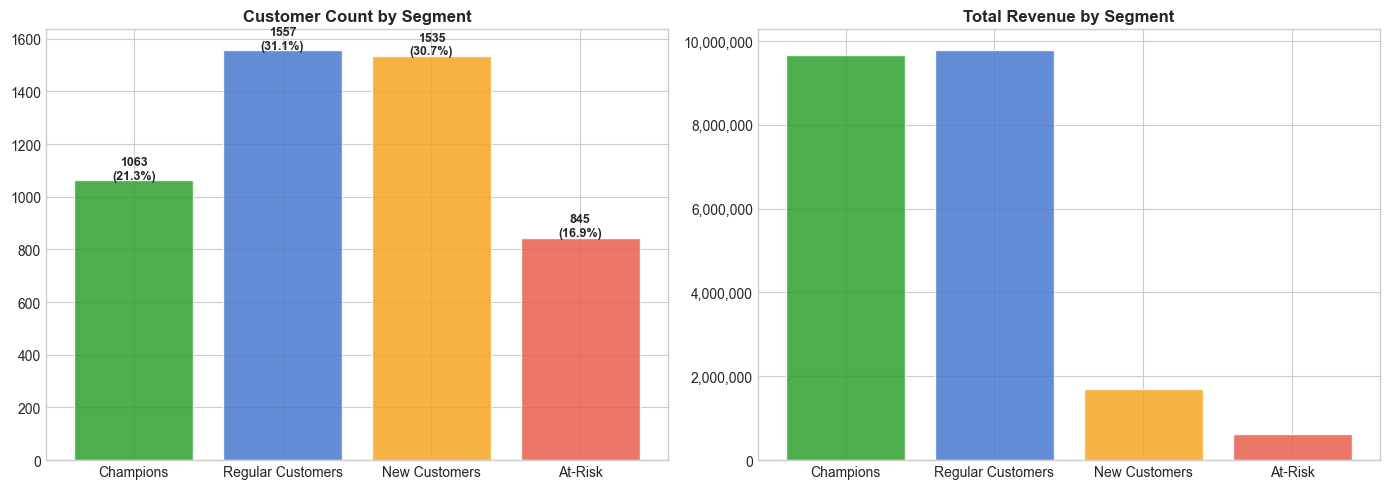

Revenue at risk (At-Risk segment): 628,032 (2.9% total)


In [37]:
# 10.2  Segment revenue breakdown
seg_order  =['Champions','Regular Customers','New Customers','At-Risk']
seg_colors ={'Champions':'#2ca02c','Regular Customers':'#4878cf',
             'New Customers':'#f5a623','At-Risk':'#e8604c'}
seg_counts  =cf['Segment'].value_counts().reindex(seg_order,fill_value=0)
seg_revenue =cf.groupby('Segment')['Monetary'].sum().reindex(seg_order,fill_value=0)

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(seg_counts.index,seg_counts.values,
            color=[seg_colors[s] for s in seg_counts.index],alpha=0.85,edgecolor='white')
for i,v in enumerate(seg_counts.values):
    axes[0].text(i,v+5,f'{v}\n({v/len(cf)*100:.1f}%)',ha='center',fontweight='bold',fontsize=9)
axes[0].set_title('Customer Count by Segment',fontweight='bold')

axes[1].bar(seg_revenue.index,seg_revenue.values,
            color=[seg_colors[s] for s in seg_revenue.index],alpha=0.85,edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].set_title('Total Revenue by Segment',fontweight='bold')
plt.tight_layout(); plt.show()

at_risk_rev=seg_revenue.get('At-Risk',0); total_rev=seg_revenue.sum()
print(f'Revenue at risk (At-Risk segment): {at_risk_rev:,.0f} ({at_risk_rev/total_rev*100:.1f}% total)')

In [38]:
# 10.3  Priority matrix
cf['At_Risk_Prob']=lgb_tuned.predict_proba(cf[FEAT_COLS].values)[:,1]
cf['Priority']=cf['At_Risk_Prob'].apply(
    lambda p: 'HIGH PRIORITY' if p>=0.7 else 'MEDIUM' if p>=0.4 else 'LOW')

priority_summary=cf.groupby('Priority').agg(
    N_Customers  =('At_Risk_Prob','count'),
    Avg_Prob     =('At_Risk_Prob','mean'),
    Avg_Monetary =('Monetary','mean'),
    Avg_Recency  =('Recency','mean'),
    Avg_Frequency=('Frequency','mean')
).round(2)
print('Priority Matrix:'); display(priority_summary)
print()
print('ACTION ITEMS:')
print('HIGH PRIORITY (>=0.70) : Win-back ngay -- voucher ca nhan, uu dai dac biet')
print('MEDIUM        (0.40-0.70): Nurture campaign -- loyalty points, goi y san pham')
print('LOW / Champions (<0.40)  : Maintain & Upsell -- VIP tier, cross-sell premium')

Priority Matrix:


,N_Customers,Avg_Prob,Avg_Monetary,Avg_Recency,Avg_Frequency
Priority,,,,,
HIGH PRIORITY,846,1.00,745.23,223.11,1.03
LOW,4153,0.00,5091.74,104.69,3.89
MEDIUM,1,0.46,2610.15,55.00,1.00



ACTION ITEMS:
HIGH PRIORITY (>=0.70) : Win-back ngay -- voucher ca nhan, uu dai dac biet
MEDIUM        (0.40-0.70): Nurture campaign -- loyalty points, goi y san pham
LOW / Champions (<0.40)  : Maintain & Upsell -- VIP tier, cross-sell premium


## 10.4 Top 5 Business Insights

**1. Frequency la tin hieu At-Risk manh nhat** (SHAP chung minh):  
Khach mua it lan => xac suat At-Risk cao. Kich thich lan mua thu 2, thu 3 quan trong hon tim khach moi.

**2. Purchase_Velocity phat hien 'ngoi sao dang len'**:  
Velocity cao + Recency thap = dang trong giai doan trang mat => onboard loyalty ngay.

**3. log_Monetary phan anh suc chi tieu dai han**:  
Khach chi tieu it => de roi vao At-Risk. Tap trung upsell som truoc khi giam engagement.

**4. Weekend_Purchase_Ratio phan anh lifestyle**:  
Leisure shopper => campaign targeting T6-T7.

**5. Feature Engineering quyet dinh hon thuat toan**:  
LightGBM + RFM derived features >> LightGBM + raw features.

## 10.5 Han che & Huong Phat trien

**Han che:**
1. Segment 'At-Risk' dinh nghia boi KMeans -- khac dataset co the cho cluster khac
2. Dataset 14 thang -- khong nam duoc seasonality dai han
3. Khong co du lieu browsing/session/marketing context

**Huong Phat trien:**
1. **Survival Analysis** (Cox PH): du doan *khi nao* churn xay ra
2. **CLV Prediction**: tinh ROI cua retention campaign theo tung tier
3. **Real-time Scoring**: MLflow + FastAPI => score khach hang moi hang ngay

In [39]:
# 10.6  Final summary
print('='*65)
print('TOM TAT KET QUA')
print('='*65)
sil_final=silhouette_score(X_seg_scaled,cf['Cluster'])
print(f'\nSEGMENTATION (KMeans K=4):')
print(f'  Silhouette Score: {sil_final:.4f}')
for seg in ['Champions','Regular Customers','New Customers','At-Risk']:
    n=(cf['Segment']==seg).sum()
    print(f'  {seg:20s}: {n:,} ({n/len(cf)*100:.1f}%)')
print(f'\nCLASSIFICATION (At-Risk):')
print(f'  Best model : LightGBM Tuned')
print(f'  AUC        : {r_tuned["AUC"]:.4f}')
print(f'  F1-Score   : {r_tuned["F1"]:.4f}')
print(f'  Precision  : {r_tuned["Precision"]:.4f}')
print(f'  Recall     : {r_tuned["Recall"]:.4f}')
print(f'  Top 3 SHAP : {top3_feat}')
print('\nNOTEBOOK COMPLETE!')

TOM TAT KET QUA

SEGMENTATION (KMeans K=4):
  Silhouette Score: 0.2349
  Champions           : 1,063 (21.3%)
  Regular Customers   : 1,557 (31.1%)
  New Customers       : 1,535 (30.7%)
  At-Risk             : 845 (16.9%)

CLASSIFICATION (At-Risk):
  Best model : LightGBM Tuned
  AUC        : 1.0000
  F1-Score   : 0.9971
  Precision  : 0.9941
  Recall     : 1.0000
  Top 3 SHAP : ['Purchase_Velocity', 'Days_As_Customer', 'Monetary']

NOTEBOOK COMPLETE!
